# Методы кластеризации



In [1]:
# !pip install scikit-learn matplotlib seaborn umap-learn sentence-transformers \
#              torch torchvision Pillow tqdm scipy -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import warnings, time
warnings.filterwarnings('ignore')
np.random.seed(42)


from sklearn.cluster import (
    KMeans, MiniBatchKMeans, DBSCAN, HDBSCAN,
    AgglomerativeClustering, SpectralClustering,
    MeanShift, Birch, OPTICS, AffinityPropagation
)
from sklearn.mixture import GaussianMixture

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    calinski_harabasz_score, davies_bouldin_score
)

from sklearn.datasets import (
    make_blobs, make_moons, make_circles,
    make_classification, load_digits, fetch_20newsgroups
)
from sklearn.feature_extraction.text import TfidfVectorizer

print('✅ All imports successful')

✅ All imports successful


# K-Means by hands

В этом разделе мы реализруем алгоритм K-Means самостоятельно. Напомним, как вообще выглядит алгоритм:

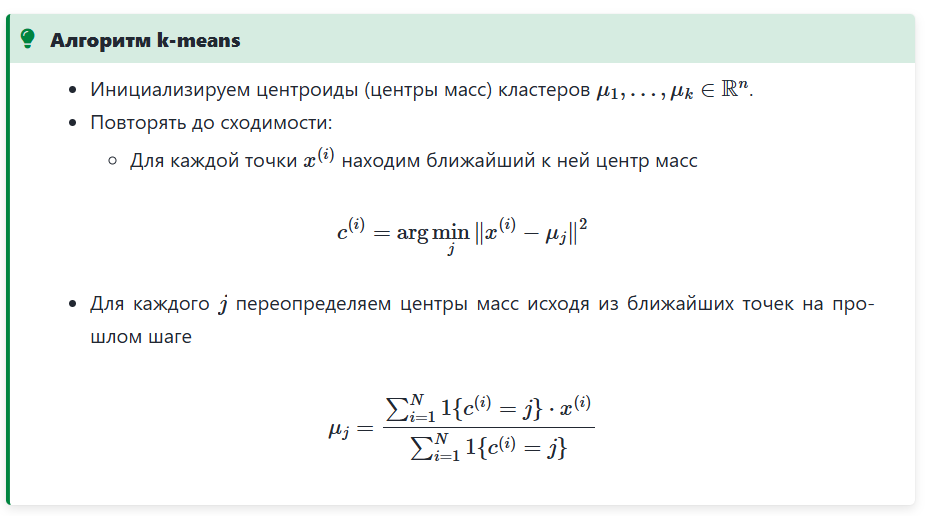

In [ ]:
import numpy as np

class KMeansCustom:
    def __init__(self, k=3, max_iters=1000, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol # Порог сходимости
        self.centroids = None

    def fit(self, X):
        # YOUR CODE IS HERE

    def predict(self, X):
        # YOUR CODE IS HERE



Давайте сравним наш алгоритм с уже реализованным алгоритмом в `sklearn`.

Подготовим данные.

In [ ]:
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

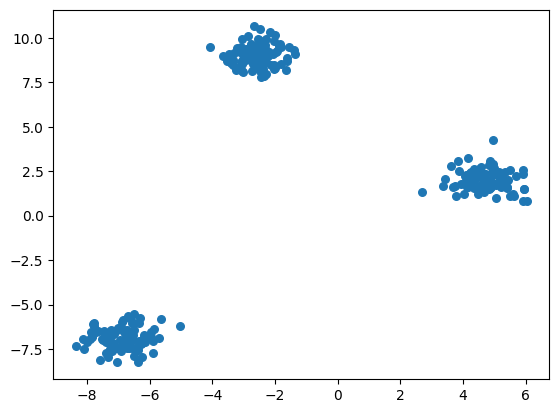

In [ ]:
plt.scatter(X[:, 0], X[:, 1], s=30, cmap='viridis')
plt.show()

In [ ]:
# --- Твой KMeans ---
my_km = KMeansCustom(k=3,  max_iters=10000, tol=1e-4,)
start = time.time()
my_km.fit(X)
my_time = time.time() - start
my_centers = my_km.centroids

# --- Sklearn KMeans ---
# n_init=1 делает сравнение честным по количеству вычислений
sk_km = KMeans(n_clusters=3, n_init=1, max_iter=10000, tol=1e-4, random_state=42)
start = time.time()
sk_km.fit(X)
sk_time = time.time() - start
sk_centers = sk_km.cluster_centers_

print(f"--- Результаты (на 10к точках) ---")
print(f"Твой код:    {my_time:.4f} сек")
print(f"Sklearn:     {sk_time:.4f} сек")
print("\nЦентроиды (Твои):\n", my_centers)
print("\nЦентроиды (Sklearn):\n", sk_centers)


--- Результаты (на 10к точках) ---
Твой код:    0.0023 сек
Sklearn:     0.0057 сек

Центроиды (Твои):
 [[-6.88217395 -6.94243433]
 [-2.58361866  9.03185632]
 [ 4.70421356  1.99562444]]

Центроиды (Sklearn):
 [[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]


Давайте посмотрим на графики

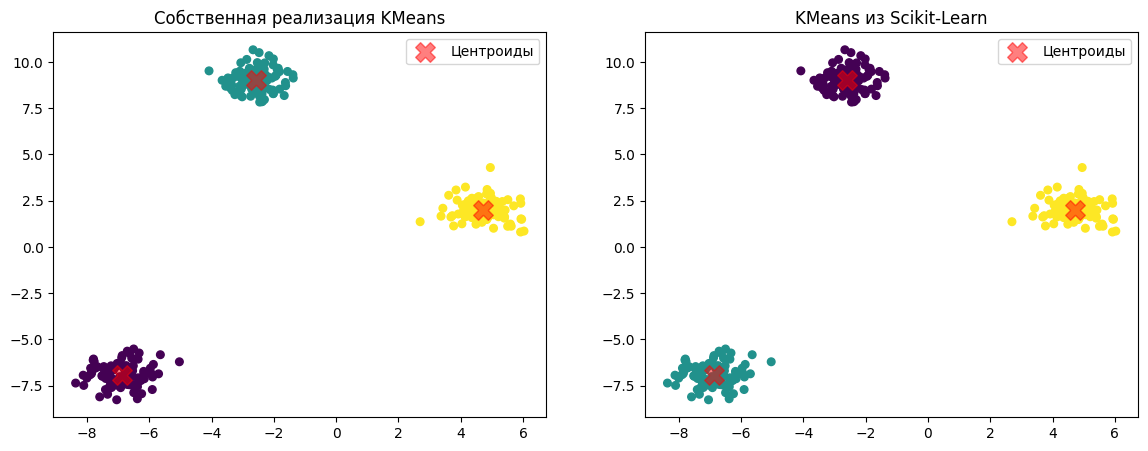

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График для нашего класса
ax1.scatter(X[:, 0], X[:, 1], c=my_km.predict(X), s=30, cmap='viridis')
ax1.scatter(my_km.centroids[:, 0], my_km.centroids[:, 1], c='red', s=200, alpha=0.5, marker='X', label='Центроиды')
ax1.set_title("Собственная реализация KMeans")
ax1.legend()

# График для Scikit-Learn
ax2.scatter(X[:, 0], X[:, 1], c=sk_km.labels_, s=30, cmap='viridis')
ax2.scatter(sk_km.cluster_centers_[:, 0], sk_km.cluster_centers_[:, 1], c='red', s=200, alpha=0.5, marker='X', label='Центроиды')
ax2.set_title("KMeans из Scikit-Learn")
ax2.legend()

plt.show()


In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


class KMeansAnimated(KMeansCustom):
    def fit(self, X):
        self.history = []
        X = np.array(X)
        random_indices = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iters):
            self.history.append(self.centroids.copy())
            labels = self.create_clusters(X)
            old_centroids = self.centroids.copy()
            self.centroids = self.update_centroids(X, labels)
            if np.all(np.abs(old_centroids - self.centroids) < self.tol):
                break
        self.history.append(self.centroids.copy())

num_clusters = 3

model = KMeansAnimated(k=num_clusters)
model.fit(X)

fig, ax = plt.subplots(figsize=(8, 5))

def update(frame):
    ax.clear()
    curr_centroids = model.history[frame]
    dist = np.sqrt(((X[:, np.newaxis] - curr_centroids)**2).sum(axis=2))
    labels = np.argmin(dist, axis=1)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.5)
    ax.scatter(curr_centroids[:, 0], curr_centroids[:, 1],
               c='red', s=200, marker='X', edgecolors='black', label='Центроиды')
    ax.set_title(f"K-Means Итерация: {frame}")
    ax.set_xticks([]); ax.set_yticks([])

ani = FuncAnimation(fig, update, frames=len(model.history), interval=600)

plt.close()
HTML(ani.to_html5_video())

---
# Toy Examples

Для начала давайте попробуем посмотреть некоторые игрушечные примеры и протестируем различные алгоритмы кластеризации.

## Подгрузка данных

Мы с вами 5 разных примеров различных датасетов:

Давайте посмотрим, как выглядят наши данные.

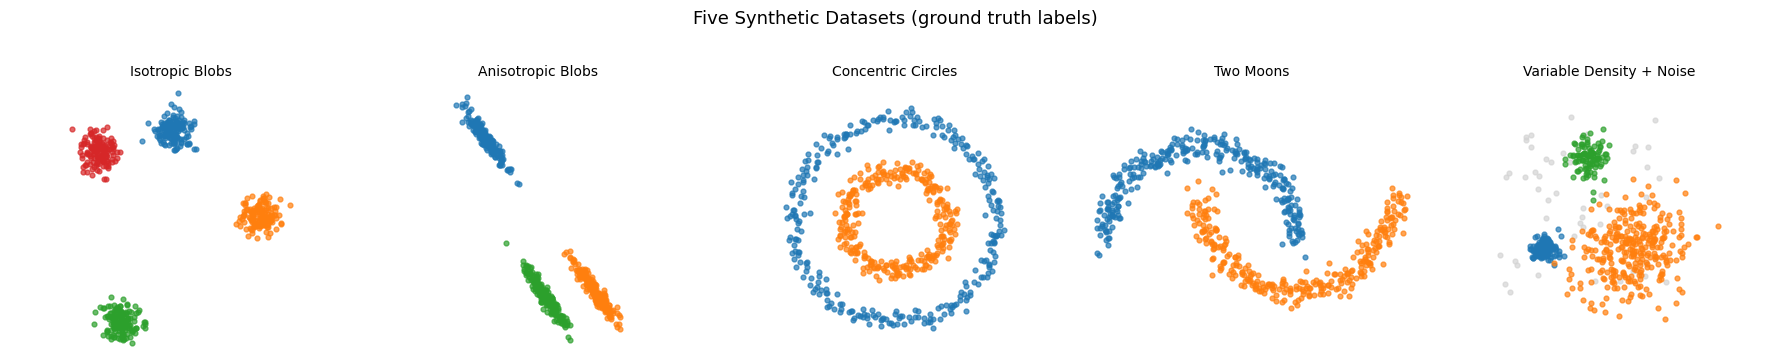

In [ ]:
N = 600

# 1. Isotropic blobs
X_blobs, y_blobs = make_blobs(n_samples=N, centers=4, cluster_std=0.8, random_state=42)

# 2. Anisotropic blobs
X_raw, y_aniso = make_blobs(n_samples=N, centers=3, random_state=42)
T = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_aniso = X_raw @ T

# 3. Concentric circles
X_circles, y_circles = make_circles(n_samples=N, factor=0.5, noise=0.05, random_state=42)

# 4. Two moons
X_moons, y_moons = make_moons(n_samples=N, noise=0.07, random_state=42)

# 5. Clusters with different densities + noise
rng = np.random.default_rng(42)
c1 = rng.normal([0, 0], 0.3, (150, 2))
c2 = rng.normal([4, 0], 1.2, (300, 2))
c3 = rng.normal([2, 4], 0.5, (100, 2))
noise_pts = rng.uniform(-2, 6, (50, 2))
X_density = np.vstack([c1, c2, c3, noise_pts])
y_density = np.array([0]*150 + [1]*300 + [2]*100 + [-1]*50)

datasets = [
    (X_blobs,   y_blobs,   'Isotropic Blobs',          4),
    (X_aniso,   y_aniso,   'Anisotropic Blobs',         3),
    (X_circles, y_circles, 'Concentric Circles',        2),
    (X_moons,   y_moons,   'Two Moons',                 2),
    (X_density, y_density, 'Variable Density + Noise',  3),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, (X, y, title, _) in zip(axes, datasets):
    unique = np.unique(y)
    for c in unique:
        mask = y == c
        color = 'lightgray' if c == -1 else plt.cm.tab10(int(c))
        ax.scatter(X[mask, 0], X[mask, 1], s=12, color=color, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.axis('equal'); ax.axis('off')

plt.suptitle('Five Synthetic Datasets (ground truth labels)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Тестирование алгоритмов

Далее мы посмотрим несколько различных алгоритмов и как они работают. Мы будем пользоваться библиотекой `sklearn`. Давайте посмотрим, какие вообще есть [функции](https://scikit-learn.org/stable/modules/clustering.html#k-means) там.

### KMeans

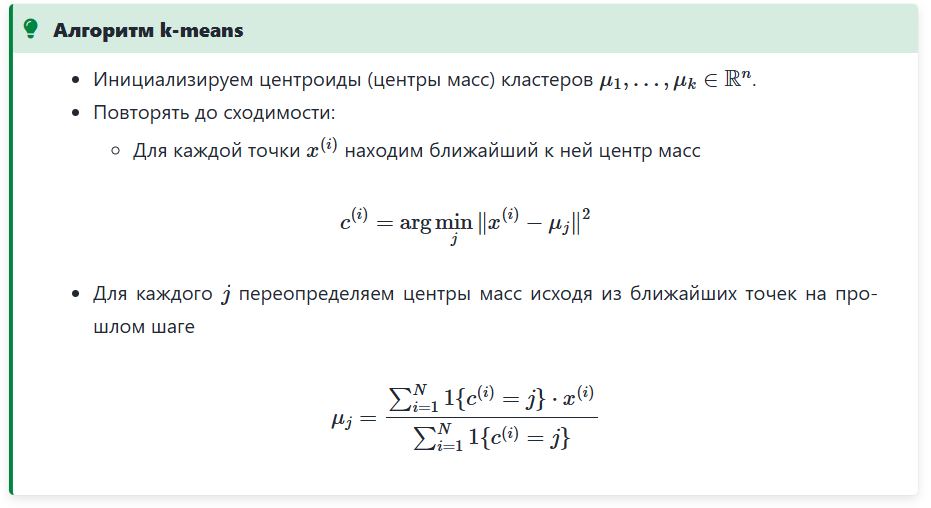

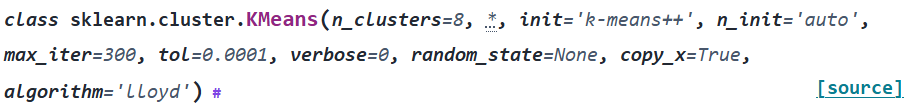

Мы уже знаем про количество кластеров, параметры `max_iter` и `tol`. `init='k-means++'` -- более умная, чем просто рандомная инициализация. Первый центроид выбирается **случайно**, а каждый следующий — **максимально далеко** от уже существующих.

### DBSCAN

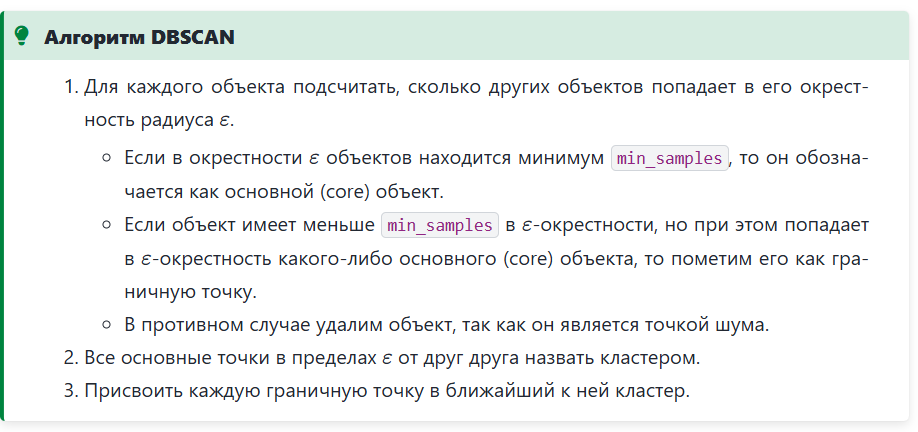

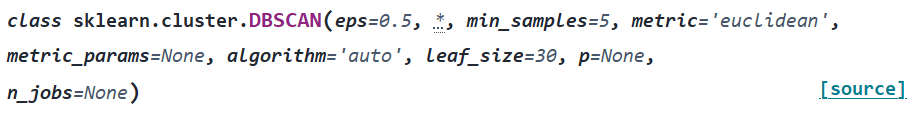

### Тест

Давайте протестируем алгоритмы

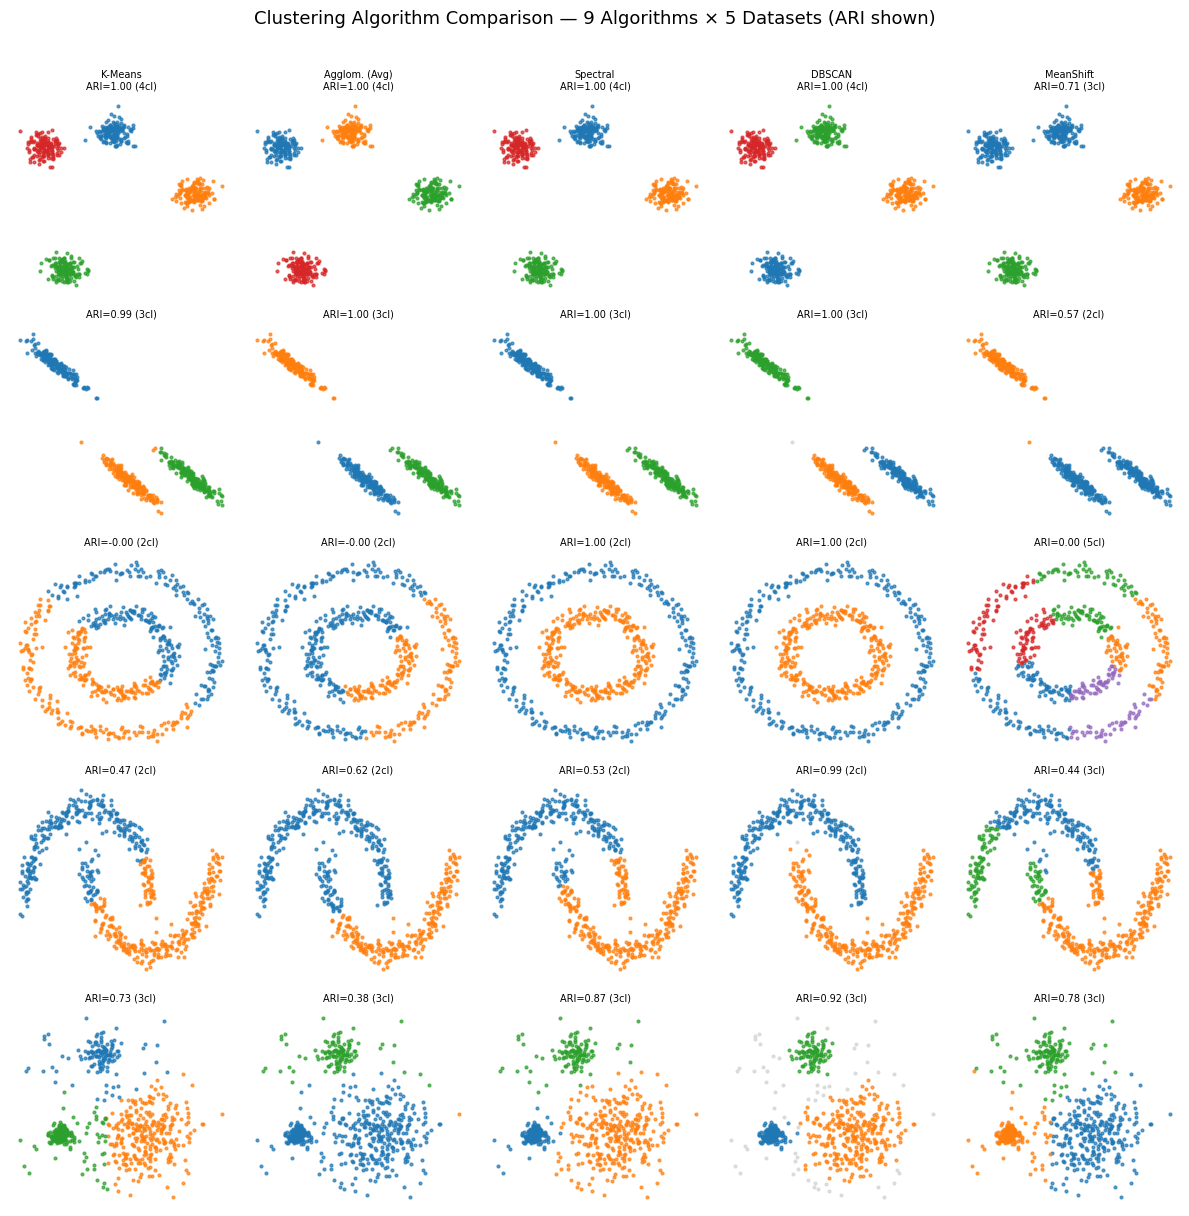

In [ ]:
def make_algorithms(k, X):
    """Return dict of algorithm instances tuned for k clusters."""
    bandwidth = max(0.5, np.std(X) * 0.8)
    return {
        'K-Means':        KMeans(n_clusters=k, random_state=42, n_init=10),
        'Agglom. (Avg)':  AgglomerativeClustering(n_clusters=k, linkage='average'),
        'Spectral':       SpectralClustering(n_clusters=k, random_state=42, n_neighbors=10, affinity='nearest_neighbors'),
        'DBSCAN':         DBSCAN(eps=0.3, min_samples=8),
        'MeanShift':      MeanShift(bandwidth=bandwidth),
    }

algo_names = list(make_algorithms(2, np.zeros((10,2))).keys())

fig, axes = plt.subplots(len(datasets), len(algo_names),
                          figsize=(len(algo_names)*2.4, len(datasets)*2.4))

score_table = []  # for later summary

for row, (X, y_true, ds_name, k) in enumerate(datasets):
    X_sc = StandardScaler().fit_transform(X)
    algos = make_algorithms(k, X_sc)

    for col, (algo_name, algo) in enumerate(algos.items()):
        ax = axes[row, col]
        t0 = time.time()
        try:
            if hasattr(algo, 'fit_predict'):
                labels = algo.fit_predict(X_sc)
            else:
                algo.fit(X_sc)
                labels = algo.predict(X_sc)
            elapsed = time.time() - t0

            # mask noise for ARI
            mask = labels != -1
            ari = adjusted_rand_score(y_true[mask], labels[mask]) if mask.sum() > 10 else 0.0
            n_cl = len(set(labels) - {-1})

            # plot
            unique_lbs = sorted(set(labels))
            for lb in unique_lbs:
                m = labels == lb
                c = 'lightgray' if lb == -1 else plt.cm.tab10(lb % 10)
                ax.scatter(X_sc[m, 0], X_sc[m, 1], s=4, color=c, alpha=0.7)
            ax.set_title(f'ARI={ari:.2f} ({n_cl}cl)', fontsize=7)
            score_table.append((ds_name, algo_name, ari, n_cl, elapsed))
        except Exception as e:
            ax.text(0.5, 0.5, 'ERR', transform=ax.transAxes, ha='center')
            score_table.append((ds_name, algo_name, np.nan, 0, 0))

        ax.axis('off')
        if row == 0: ax.set_title(f'{algo_name}\n' + ax.get_title(), fontsize=7)
        if col == 0: ax.set_ylabel(ds_name, fontsize=8, rotation=90, labelpad=4)

plt.suptitle('Clustering Algorithm Comparison — 5 Algorithms × 5 Datasets (ARI shown)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Оценка качества

#### ARI(Adjusted Rand Index)

Индекс Rand оценивает, насколько много из тех пар элементов, которые находились в одном классе, и тех пар элементов, которые находились в разных классах, сохранили это состояние после кластеризации алгоритмом. Имеет область определения от 0 до 1, где 1 — полное совпадение кластеров с заданными классами, а 0 — отсутствие совпадений.



Rand Index:
$$RI = \frac{TP + TN}{\binom{n}{2}} = \frac{\sum_{ij} \binom{n_{ij}}{2} + \left[ \binom{n}{2} - \sum_i \binom{a_i}{2} - \sum_j \binom{b_j}{2} + \sum_{ij} \binom{n_{ij}}{2} \right]}{\binom{n}{2}}$$

$E[RI] = \frac{ \left( \sum_i \binom{a_i}{2} \right) \left( \sum_j \binom{b_j}{2} \right) }{ \binom{n}{2} }$

$  a_i = \sum_j n_{ij}  $ — размер кластера $  U_i  $ (строки).

$  b_j = \sum_i n_{ij}  $ — размер кластера $  V_j  $ (столбцы).

$$ARI = \frac{ \sum_{ij} \binom{n_{ij}}{2} - E[RI] }{ \frac{1}{2} \left( \sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2} \right) - E[RI] }$$


В отличие от обычного индекса Rand, индекс Adjusted Rand может принимать отрицательные значения, если Index<ExpectedIndex

Попробуем посмотреть, какой из алгоритмов имеет наилучший результат

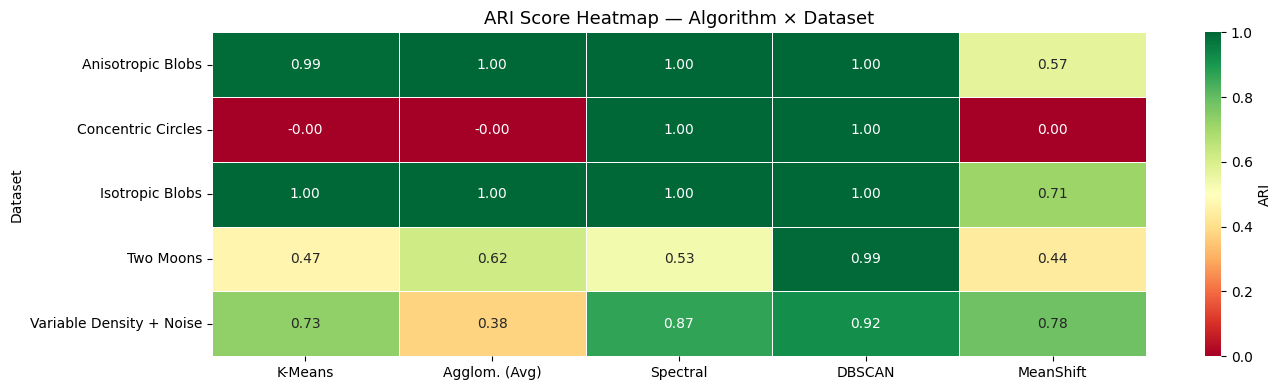


🏆 Best algorithm per dataset:
  Anisotropic Blobs              → Agglom. (Avg)  (ARI=1.000)
  Concentric Circles             → Spectral  (ARI=1.000)
  Isotropic Blobs                → K-Means  (ARI=1.000)
  Two Moons                      → DBSCAN  (ARI=0.993)
  Variable Density + Noise       → DBSCAN  (ARI=0.922)


In [ ]:
df_scores = pd.DataFrame(score_table, columns=['Dataset','Algorithm','ARI','N_clusters','Time_s'])
pivot_ari = df_scores.pivot(index='Dataset', columns='Algorithm', values='ARI')[algo_names]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_ari.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax, cbar_kws={'label': 'ARI'})
ax.set_title('ARI Score Heatmap — Algorithm × Dataset', fontsize=13)
ax.set_xlabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Best algorithm per dataset
print('Best algorithm per dataset:')
for ds in pivot_ari.index:
    row_v = pivot_ari.loc[ds].dropna()
    best = row_v.idxmax()
    print(f'  {ds:<30} → {best}  (ARI={row_v[best]:.3f})')

## Скорость vs качество

Часто в задаче влияет не только качество, но и скорость. Иногда это является критическим моментом при решении заданий

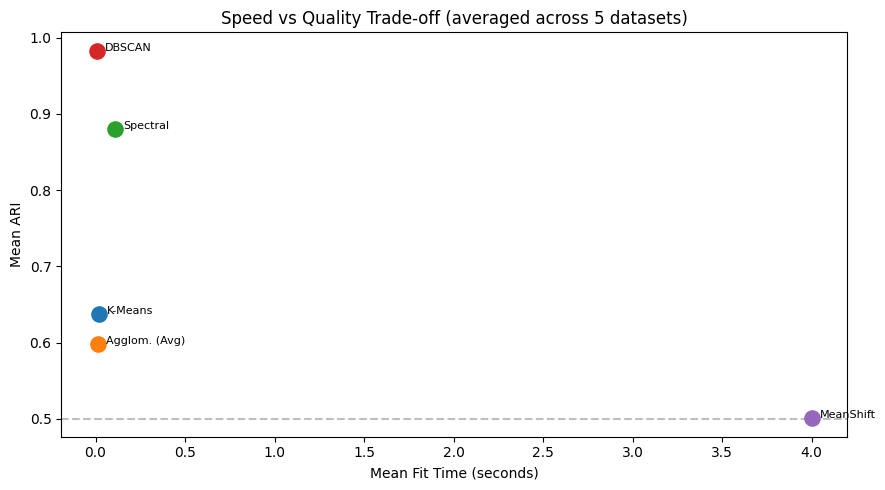

In [ ]:
mean_ari = df_scores.groupby('Algorithm')[['ARI','Time_s']].mean().reindex(algo_names)

fig, ax = plt.subplots(figsize=(9, 5))
for i, algo in enumerate(algo_names):
    row = mean_ari.loc[algo]
    ax.scatter(row['Time_s'], row['ARI'], s=120, zorder=3,
               color=plt.cm.tab10(i), label=algo)
    ax.annotate(algo, (row['Time_s'], row['ARI']),
                textcoords='offset points', xytext=(6, 0), fontsize=8)

ax.set_xlabel('Mean Fit Time (seconds)')
ax.set_ylabel('Mean ARI')
ax.set_title('Speed vs Quality Trade-off (averaged across 5 datasets)', fontsize=12)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='ARI=0.5 baseline')
plt.tight_layout()
plt.show()

Посмотрите на график. Какие выводы Вы можете сделать?

## Нормализация для кластеров

Мы берём одни и те же данные с тремя истинными кластерами, но меняем только предобработку признаков:

* без масштабирования,

* StandardScaler,

* L2-нормализация.

Для каждой версии данных запускаем K-Means с
k=3 и считаем ARI относительно истинных меток. Это показывает, насколько чувствителен K-Means к масштабу признаков.

In [ ]:

preprocessors = [
    ('Raw (no scaling)',    X_raw_scale),
    ('StandardScaler',     StandardScaler().fit_transform(X_raw_scale)),
    ('L2 Normalise',       normalize(X_raw_scale)),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, X_pp) in zip(axes, preprocessors):
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    lbs = km.fit_predict(X_pp)
    ari = adjusted_rand_score(y_raw_scale, lbs)
    for c in range(3):
        m = lbs == c
        ax.scatter(X_pp[m, 0], X_pp[m, 1], s=18, alpha=0.7,
                   color=plt.cm.tab10(c))
    ax.set_title(f'{name}\nK-Means ARI = {ari:.3f}', fontsize=10)
    ax.axis('off')

plt.suptitle('Impact of Feature Scaling on K-Means (same data, 3 preprocessing choices)',
             fontsize=12)
plt.tight_layout()
plt.show()

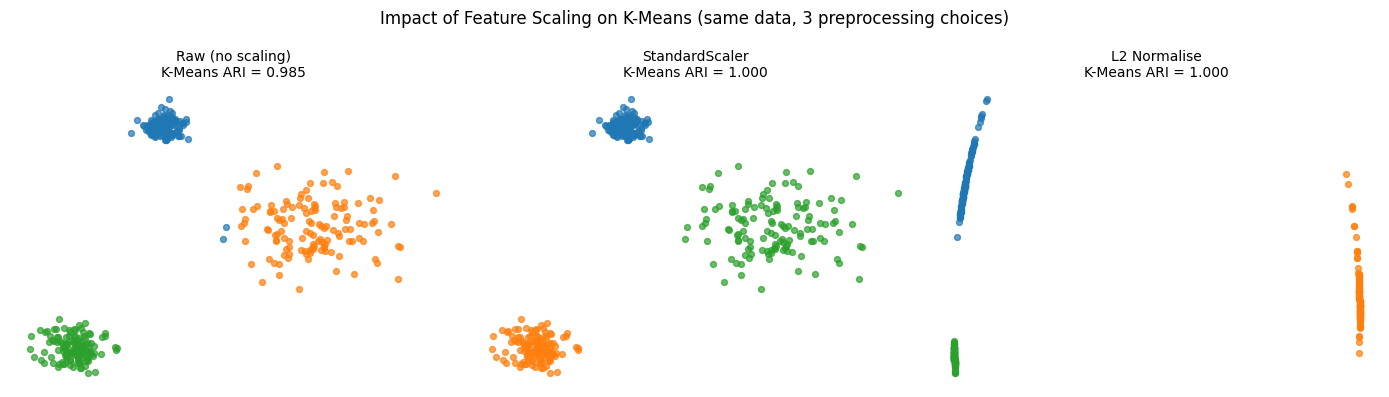

In [ ]:
# Create blobs with very different scales
X_raw_scale, y_raw_scale = make_blobs(n_samples=400, centers=3,
                                       cluster_std=[0.5, 2.0, 0.8], random_state=42)
X_raw_scale[:, 0] *= 10  # exaggerate axis 0



Что видно на графике

* При Raw (no scaling) один признак доминирует, облака растянуты, ARI чуть меньше 1: алгоритм иногда путается на границах кластеров.

* При StandardScaler кластеры становятся более «круглыми» и сравнимыми по масштабу, K-Means идеально восстанавливает разметку (ARI = 1.0).

* При L2 Normalise данные выстраиваются вдоль оси (модуль вектора фиксирован), но кластеры всё ещё хорошо разделимы, поэтому ARI тоже = 1.0; при более сложных данных такая нормализация может, наоборот, испортить структуру.

Вывод: для K-Means масштабирование признаков критично: алгоритм минимизирует евклидово расстояние, и признак с большим масштабом может полностью доминировать. Лучше всегда явно контролировать скейлинг, чем полагаться на «сырые» значения.

## 0.7 — Нетривиально: устойчивость кластеризации через бутстрап

**Идея**: хорошая кластеризация должна быть **устойчивой** — если заново запустить алгоритм на слегка возмущённых данных, результат должен быть тем же.  
Мы делаем бутстрап 30 подвыборок и измеряем, насколько последовательно K-Means выбирает K=4 по сравнению с другими значениями K.

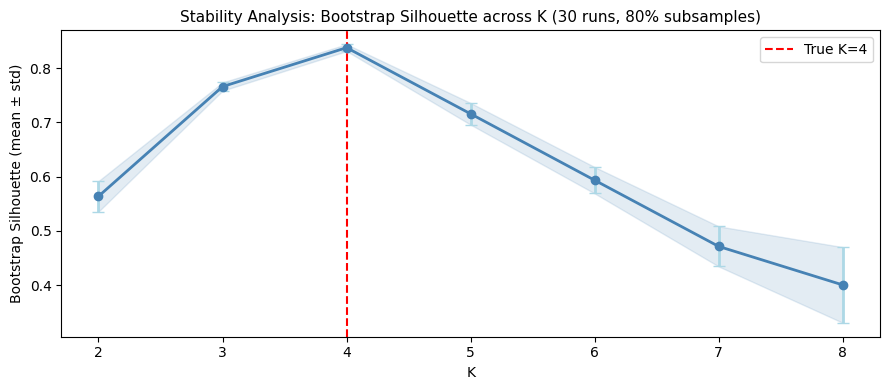

Insight: low std at the peak K indicates a stable, reliable partition.


In [ ]:
X_sc = StandardScaler().fit_transform(X_blobs)
N_BOOT = 30
K_RANGE = range(2, 9)

boot_sils = {k: [] for k in K_RANGE}

for _ in range(N_BOOT):
    idx = np.random.choice(len(X_sc), size=int(0.8 * len(X_sc)), replace=True)
    X_boot = X_sc[idx]
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=3, random_state=None)
        lbs = km.fit_predict(X_boot)
        boot_sils[k].append(silhouette_score(X_boot, lbs, sample_size=200))

means = [np.mean(boot_sils[k]) for k in K_RANGE]
stds  = [np.std(boot_sils[k])  for k in K_RANGE]

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(list(K_RANGE), means, yerr=stds, fmt='o-', capsize=4,
            color='steelblue', ecolor='lightblue', linewidth=2)
ax.axvline(4, color='red', linestyle='--', label='True K=4')
ax.fill_between(list(K_RANGE),
                [m-s for m,s in zip(means,stds)],
                [m+s for m,s in zip(means,stds)],
                alpha=0.15, color='steelblue')
ax.set_xlabel('K')
ax.set_ylabel('Bootstrap Silhouette (mean ± std)')
ax.set_title('Stability Analysis: Bootstrap Silhouette across K (30 runs, 80% subsamples)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()
print('Insight: low std at the peak K indicates a stable, reliable partition.')

---
**Задания**
1) Попробуйте посмотреть, как остальные алгоритмы, кроме k-means, ведут себя при нормализации? Какой метод для какого алгоритма лучше всего подходит? Как соотносится время работы алгоритма и его качество?
2) На лекции у Вас было много разных метрик. Реализуйте 3 их них. Вам нужно реализовать и описать, почему для какого-либо алгоритма эта метрика подходит лучше всего для оценки.

---
# Computer Vision Clustering

## MNIST (Pixel Features)

**Dataset**: `sklearn.datasets.load_digits` (8×8, 1797 samples)  


Рассмотрим датасет из рукописных цифр. Всего в ней 10 классов, а размер каждой картинки $8 \times 8$.

Dataset shape : (1797, 64)
Classes       : [0 1 2 3 4 5 6 7 8 9]


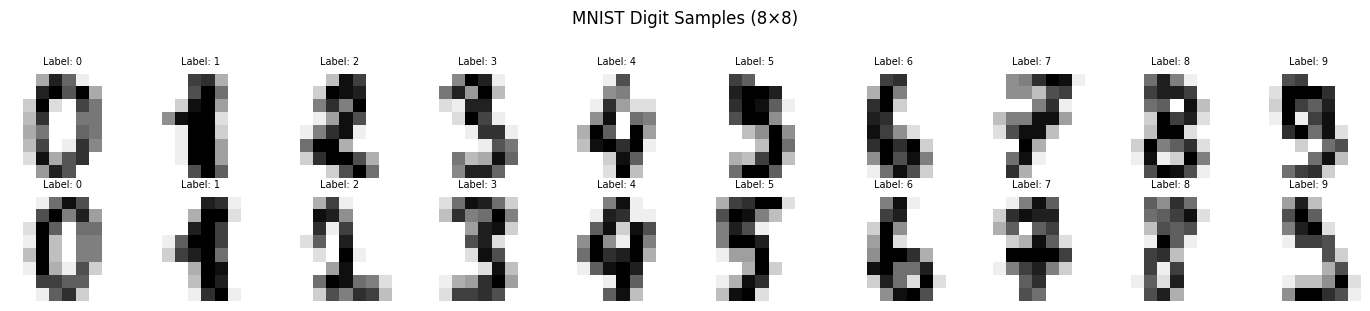

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data          # (1797, 64) — flattened 8x8 images
y_digits = digits.target        # true labels 0-9

print(f'Dataset shape : {X_digits.shape}')
print(f'Classes       : {np.unique(y_digits)}')

# Preview some images
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f'Label: {y_digits[i]}', fontsize=7)
    ax.axis('off')
plt.suptitle('MNIST Digit Samples (8×8)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Нормализуем и зафитим

In [ ]:
# ── K-Means clustering ──────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, labels_km, sample_size=500)
ari = adjusted_rand_score(y_digits, labels_km)
print(f'K-Means  →  Silhouette: {sil:.3f}  |  ARI: {ari:.3f}')

K-Means  →  Silhouette: 0.148  |  ARI: 0.534


## 2D Visualisation:t-SNE, UMAP (True Labels & Predicted)

Давайте посмотрим, как выглядят наши кластеры в 2D

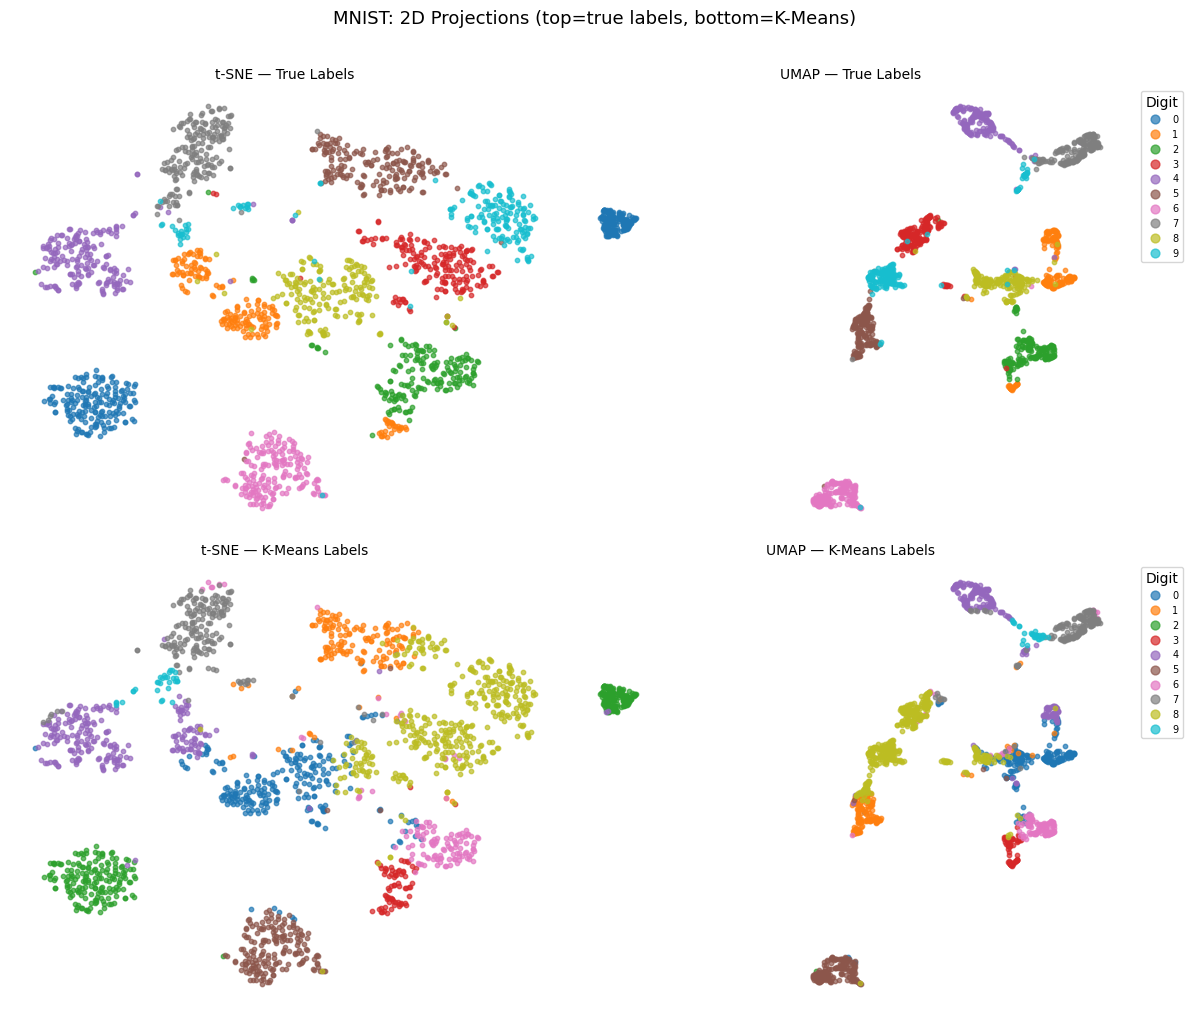

In [ ]:
tsne2 = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne_d = tsne2.fit_transform(X_scaled)


import umap
X_umap_d = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)
projs = [('t-SNE', X_tsne_d), ('UMAP', X_umap_d)]


fig, axes = plt.subplots(2, len(projs), figsize=(6*len(projs), 10))

for col, (pname, X2d) in enumerate(projs):
    for row, (lbs, title) in enumerate([(y_digits, 'True'), (labels_km, 'K-Means')]):
        ax = axes[row, col]
        for c in range(10):
            m = lbs == c
            ax.scatter(X2d[m, 0], X2d[m, 1], s=10, alpha=0.7,
                       color=plt.cm.tab10(c), label=str(c))
        ax.set_title(f'{pname} — {title} Labels', fontsize=10)
        ax.axis('off')
        if col == len(projs)-1:
            ax.legend(title='Digit', markerscale=2, fontsize=7,
                      bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('MNIST: 2D Projections (top=true labels, bottom=K-Means)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Confusion Matrix

Сейчас у нас есть случайные кластеры. Они не обязтельно идут в таком же порядке, в котором идут наши лейблы для цифр (можете убедиться в этом на картинке выше). Для того, чтобы "подружить" наши лейблы и кластеры мы хотим сделать следующее:

1. Сначала мы строим обычную матрицу ошибок. Строки — это реальные цифры (0–9), столбцы — номера кластеров, которые выдал K-Means. На пересечении стоит количество картинок.

2. Используем [Венгерский](https://habr.com/ru/articles/422009/) алгоритм, который находит такие пары «Номер кластера <—> Реальная цифра», чтобы суммарное количество правильно угаданных картинок во всех парах было максимально возможным.

Cluster Purity (Hungarian matched): 0.663


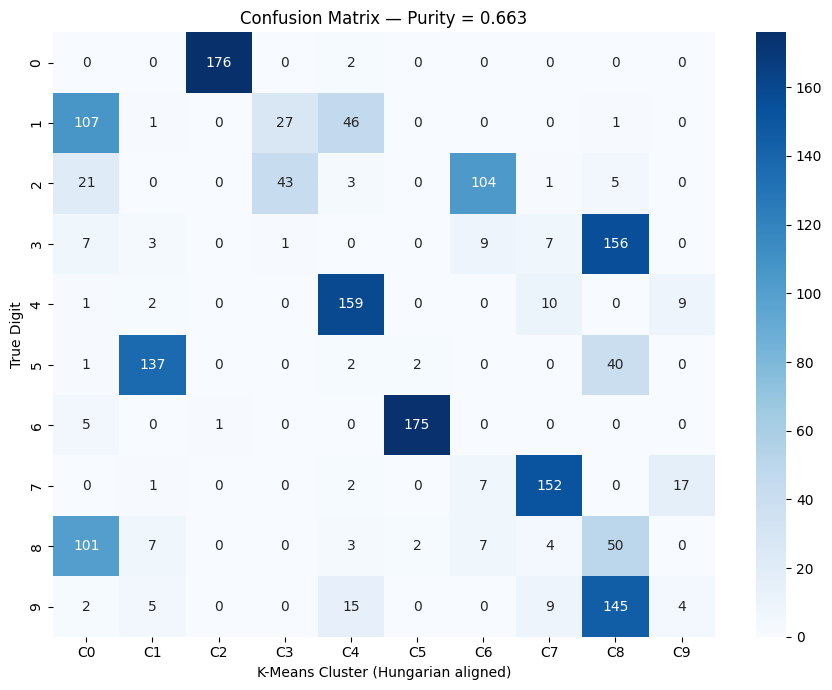

In [ ]:
# @title
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

# Hungarian algorithm to align cluster IDs with digit labels
cm = confusion_matrix(y_digits, labels_km)
row_ind, col_ind = linear_sum_assignment(-cm)
purity = cm[row_ind, col_ind].sum() / len(y_digits)
print(f'Cluster Purity (Hungarian matched): {purity:.3f}')

# Reorder columns for aligned heatmap
cm_reordered = cm[:, col_ind]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f'C{i}' for i in range(10)],
            yticklabels=list(range(10)))
ax.set_xlabel('K-Means Cluster (Hungarian aligned)')
ax.set_ylabel('True Digit')
ax.set_title(f'Confusion Matrix — Purity = {purity:.3f}', fontsize=12)
plt.tight_layout()
plt.show()

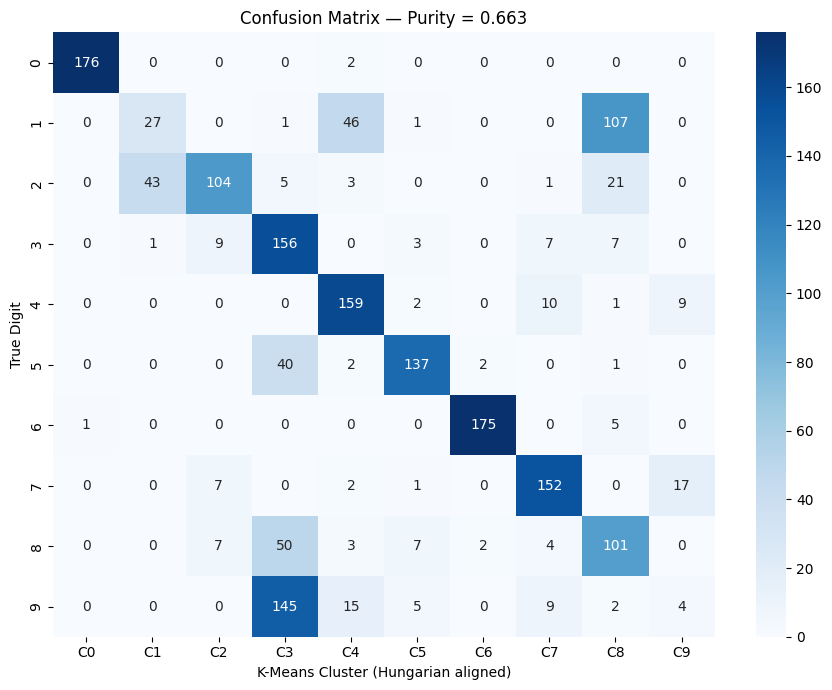

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_reordered, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f'C{i}' for i in range(10)],
            yticklabels=list(range(10)))
ax.set_xlabel('K-Means Cluster (Hungarian aligned)')
ax.set_ylabel('True Digit')
ax.set_title(f'Confusion Matrix — Purity = {purity:.3f}', fontsize=12)
plt.tight_layout()
plt.show()

## CIFAR-10

**Dataset**: CIFAR-10

Давайте теперь рассмотрим еще один датасет с картинками.

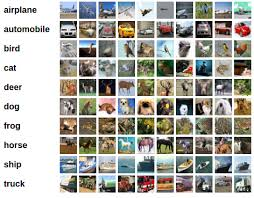

In [ ]:
import torch
import torchvision, torchvision.transforms as T
from torchvision import models
from torch.utils.data import DataLoader, Subset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

full_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
subset  = Subset(full_ds, range(2000))
loader  = DataLoader(subset, batch_size=64, shuffle=False, num_workers=0)


Device: cuda


100%|██████████| 170M/170M [00:05<00:00, 31.6MB/s]


Посмотрим, что вообще есть в нашем датасете.

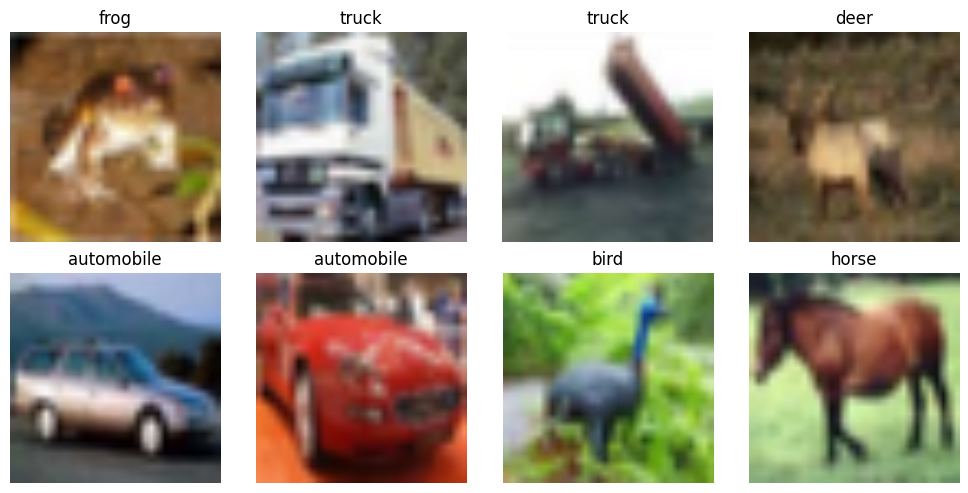


Пример: первые 8 меток → ['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse']


In [ ]:
images, labels = next(iter(loader))

# Показываем только первые 8
n_show = 8
images = images[:n_show]
labels = labels[:n_show]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_grid = images * std + mean          # денормализация
img_grid = img_grid.clamp(0, 1)
img_grid = img_grid.permute(0, 2, 3, 1)

# Классы
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Рисуем
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i in range(n_show):
    axes[i].imshow(img_grid[i].numpy())
    axes[i].set_title(class_names[labels[i].item()])
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
images.shape

torch.Size([8, 3, 224, 224])

Теперь нам надо как-то закодировать наши картинки. Для этого будем использовать модель `resnet18` (что такое resnet вы узнаете чуть позже на курсе по DL)

In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).eval().to(device)

feats, labels_c = [], []
with torch.no_grad():
    for imgs, lbs in loader:
        feats.append(extractor(imgs.to(device)).squeeze(-1).squeeze(-1).cpu().numpy())
        labels_c.extend(lbs.numpy())

X_cifar = normalize(np.vstack(feats))
y_cifar = np.array(labels_c)
class_names = full_ds.classes
print(f'CIFAR embeddings: {X_cifar.shape}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]


CIFAR embeddings: (2000, 512)


Протестируем KMeans для кластеризации наших картинок.

In [ ]:
cifar_algos = {
    'K-Means':       KMeans(n_clusters=10, random_state=42, n_init=10),
}

cifar_results = []
for name, algo in cifar_algos.items():
    t0 = time.time()
    if hasattr(algo, 'fit_predict'):
        lbs = algo.fit_predict(X_cifar)
    else:
        algo.fit(X_cifar); lbs = algo.predict(X_cifar)
    t = time.time() - t0
    mask = lbs != -1
    if mask.sum() > 50:
        ari_v = adjusted_rand_score(y_cifar[mask], lbs[mask])
        sil_v = silhouette_score(X_cifar[mask], lbs[mask], sample_size=400)
    else:
        ari_v, sil_v = 0, 0
    cifar_results.append({'Algorithm': name, 'ARI': ari_v, 'Silhouette': sil_v, 'Time_s': t})
    print(f'{name:<18}  ARI={ari_v:.3f}  Sil={sil_v:.3f}  t={t:.2f}s')

df_cifar = pd.DataFrame(cifar_results)

K-Means             ARI=0.418  Sil=0.045  t=3.37s


Давайте попробуем посмотреть, как выглядят наши кластера. Изначальная размерность фичей -- 512, её сложно визуализировать. Чтобы посмотреть как это все выгляит, давайте перейдём в 2D и посмотрим на наши кластеры.

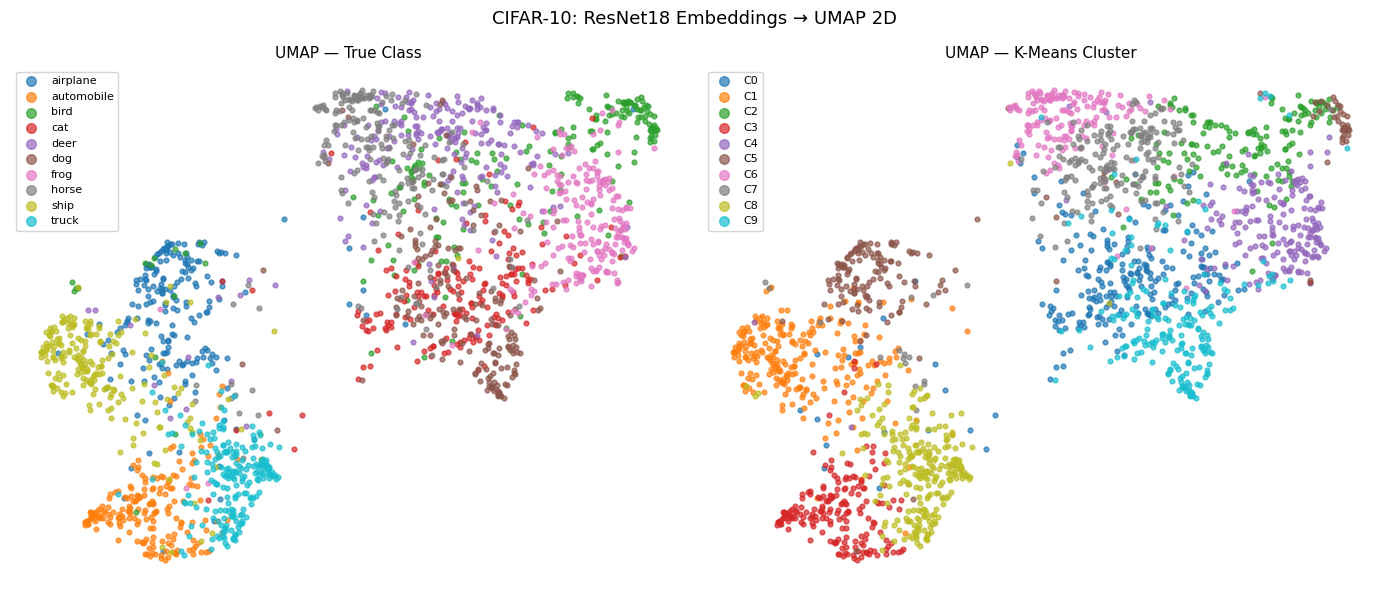

In [ ]:
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Настройка UMAP
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_cifar_2d = reducer.fit_transform(X_cifar)

# Кластеризация (оставляем K-Means, как в вашем примере)
best_lbs_cifar = KMeans(n_clusters=10, random_state=42, n_init=10).fit_predict(X_cifar)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lbs, title in [
    (axes[0], y_cifar,       'UMAP — True Class'),
    (axes[1], best_lbs_cifar,'UMAP — K-Means Cluster'),
]:
    for c in range(10):
        m = lbs == c
        lbl = class_names[c] if ax == axes[0] else f'C{c}'
        ax.scatter(X_cifar_2d[m,0], X_cifar_2d[m,1], s=12, alpha=0.7,
                   color=plt.cm.tab10(c), label=lbl)
    ax.set_title(title, fontsize=11)
    ax.legend(markerscale=2, fontsize=8, loc='best')
    ax.axis('off')

plt.suptitle('CIFAR-10: ResNet18 Embeddings → UMAP 2D', fontsize=13)
plt.tight_layout()
plt.show()

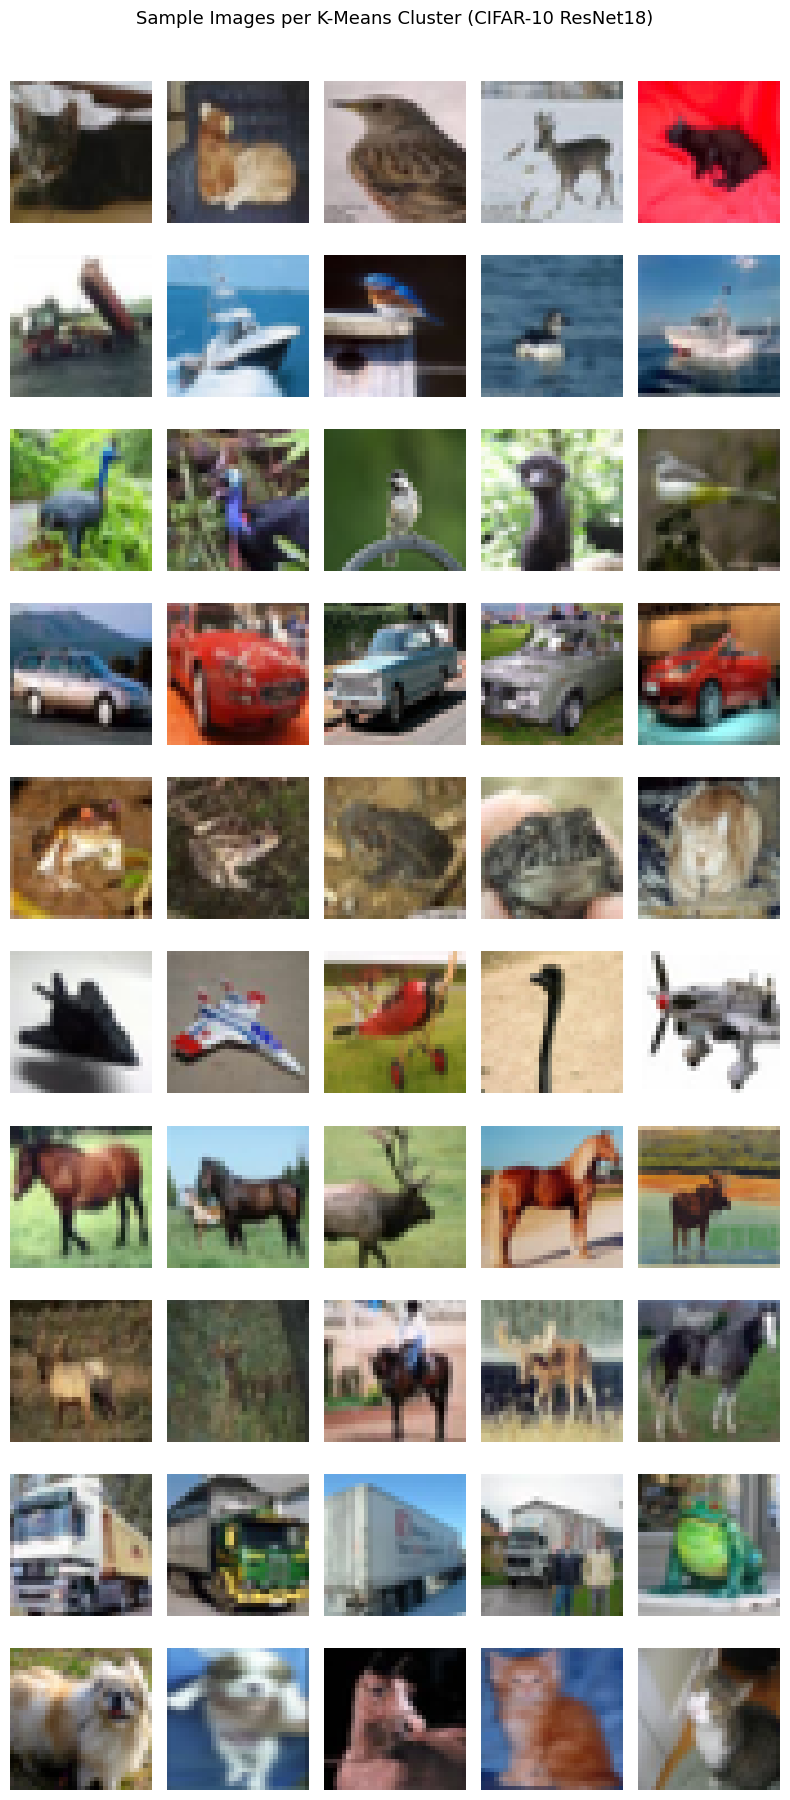

In [ ]:
# ── Grid of representative images per cluster ─────────────────────────
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

raw_ds = CIFAR10(root='./data', train=True, download=False,
                 transform=transforms.ToTensor())

fig, axes = plt.subplots(10, 5, figsize=(8, 18))
for cluster_id in range(10):
    indices = np.where(best_lbs_cifar == cluster_id)[0][:5]
    for col, idx in enumerate(indices):
        img, _ = raw_ds[idx]
        axes[cluster_id, col].imshow(img.permute(1, 2, 0).numpy())
        axes[cluster_id, col].axis('off')
    axes[cluster_id, 0].set_ylabel(f'Cluster {cluster_id}',
                                    fontsize=9, rotation=90, labelpad=4)

plt.suptitle('Sample Images per K-Means Cluster (CIFAR-10 ResNet18)',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

## Задания

1. Потестируйте различные методы кластеризации для кластеризации задач CIFAR и MNIST. Какие из них дают результаты лучше? Как вы думаете, почему?

2. Попробуйте понизить размерность, поможет ли это для улучшения качества кластеризации?

3. **Дополнительное задание**. Картинки можно кодировать по-разному. Вы можете попробовать другие кодировщики, например, [deit](https://huggingface.co/facebook/deit-small-patch16-224) или [EfficientNetV2-S](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_v2_s.html). Сейчас картинки из MNIST не кодируются вообще, может имеет смысл их закодировать?

---
# NLP Clustering

В этом разделе мы с вами рассмтрм кластеризацию тектсов

## TF-IDF + K-Means (20 Newsgroups)

**Dataset**: 20 Newsgroups  
**Auto-download**: `sklearn.datasets.fetch_20newsgroups`  

20 Newsgroups — это коллекция ≈ 18 000–20 000 реальных сообщений (постов) из Usenet-групп (предшественник современных форумов и Reddit), собранных в 1995–1996 годах.
Сообщения распределены по 20 тематическим категориям (newsgroups).

Мы с вами выберем только 6 и будем с ними работать. Всего документов будет 3511

In [ ]:
# Use a 6-category subset for clearer cluster visualisation
CATEGORIES = [
    'rec.sport.hockey',
    'rec.autos',
    'sci.space',
    'sci.med',
    'talk.politics.guns',
    'comp.graphics',
]

news = fetch_20newsgroups(subset='train', categories=CATEGORIES,
                          remove=('headers', 'footers', 'quotes'))
docs   = news.data
y_news = np.array(news.target)
print(f'Documents: {len(docs)}  |  Categories: {CATEGORIES}')

Documents: 3511  |  Categories: ['rec.sport.hockey', 'rec.autos', 'sci.space', 'sci.med', 'talk.politics.guns', 'comp.graphics']


Нам надо каким-то образом закодировать текст. Мы немного залезем в NLP часть и рассмотрим пару способо кодирования текста.

1. **TF-IDF**

TF-IDF отвечает на вопрос: «Насколько это слово важно именно для этого документа в данной коллекции текстов?»

Оно даёт высокие веса словам, которые:

- часто встречаются в этом конкретном документе
- редко встречаются в остальных документах коллекции

По сути формула состоит из 2 частей:

- TF (Term Frequency) — как часто слово встречается в данном документе

- IDF (Inverse Document Frequency) — насколько слово «редкое» в коллекции

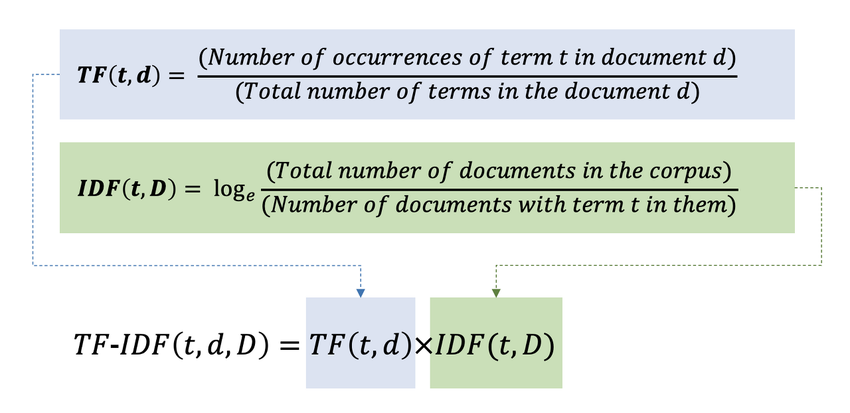

В результате алгоритм отбирает $k$ амых информативных слов.

In [ ]:
# TF-IDF vectorisation
tfidf = TfidfVectorizer(max_features=5000, stop_words='english',
                        min_df=3, max_df=0.9)
X_tfidf = tfidf.fit_transform(docs)   # sparse (N, 5000)
print(f'TF-IDF matrix: {X_tfidf.shape}')


TF-IDF matrix: (3511, 5000)


In [ ]:
words = tfidf.get_feature_names_out()

print("Всего слов:", len(words))
print("\nПервые 15 слов:", words[:15])
print("\nСлова 1000–1015:", words[1000:1015])
print("\nСлова 4000–4015:", words[4000:4015])
print("\nПоследние 15 слов:", words[-15:])

Всего слов: 5000

Первые 15 слов: ['00' '000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '1000'
 '101']

Слова 1000–1015: ['civilian' 'civilians' 'cl' 'claim' 'claimed' 'claiming' 'claims' 'clark'
 'clarke' 'class' 'classes' 'classic' 'classification' 'clean' 'cleaning']

Слова 4000–4015: ['score' 'scored' 'scorer' 'scores' 'scoring' 'scott' 'scout' 'screen'
 'screwed' 'sdi' 'sdio' 'se' 'sea' 'search' 'season']

Последние 15 слов: ['yes' 'yesterday' 'yogurt' 'york' 'young' 'younger' 'yr' 'yushkevich'
 'yzerman' 'zalapski' 'zealand' 'zelepukin' 'zero' 'zip' 'zone']


In [ ]:
km_news = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_news = km_news.fit_predict(X_tfidf)

ari_news = adjusted_rand_score(y_news, labels_news)
sil_news = silhouette_score(X_tfidf, labels_news, sample_size=500)
print(f'TF-IDF K-Means  →  ARI: {ari_news:.3f}  Silhouette: {sil_news:.3f}')

TF-IDF K-Means  →  ARI: 0.179  Silhouette: 0.015


In [ ]:
# ── Top terms per cluster ────────────────────────────────────────────
feature_names = np.array(tfidf.get_feature_names_out())
order_centroids = km_news.cluster_centers_.argsort()[:, ::-1]

print('Top 10 terms per cluster:\n')
for i in range(6):
    terms = ', '.join(feature_names[order_centroids[i, :10]])
    print(f'  Cluster {i}: {terms}')

Top 10 terms per cluster:

  Cluster 0: thanks, graphics, files, file, know, image, does, program, hi, advance
  Cluster 1: dsl, n3jxp, chastity, shameful, cadre, skepticism, intellect, geb, surrender, banks
  Cluster 2: don, just, people, like, think, know, gun, time, right, good
  Cluster 3: game, team, hockey, play, players, season, games, nhl, year, league
  Cluster 4: space, nasa, launch, moon, earth, lunar, orbit, shuttle, station, gov
  Cluster 5: car, cars, engine, dealer, like, price, just, good, new, speed


## SBERT Sentence Embeddings

**Model**: `all-MiniLM-L6-v2`  
**HuggingFace**: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

Тексты можно закодировать и по-другому. В данном случае для кодирования используется небольша трансформерная модель, которая превращает данное предложение в некоторый эмбеддинг.

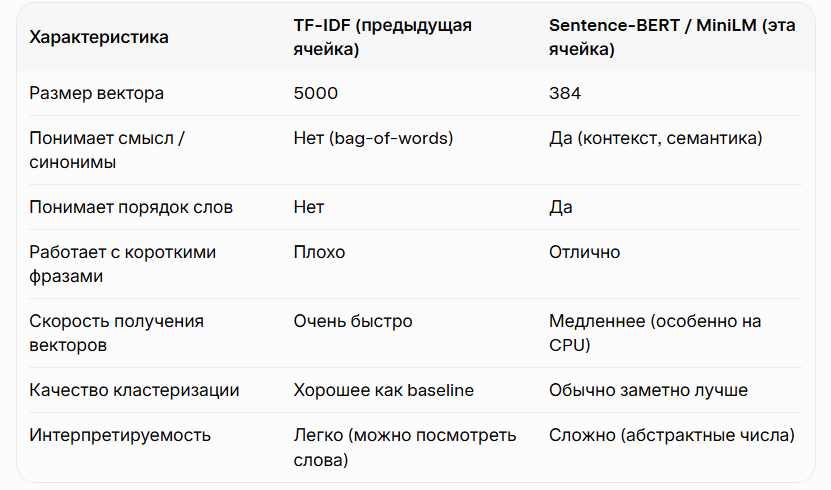

In [ ]:
from sentence_transformers import SentenceTransformer

# Use a small subset for speed
N_NLP = 1200
idx = np.random.default_rng(42).choice(len(docs), N_NLP, replace=False)
docs_sub = [docs[i] for i in idx]
y_sub    = y_news[idx]

model = SentenceTransformer('all-MiniLM-L6-v2')
# Truncate to 128 tokens for speed
X_sbert = model.encode(docs_sub, batch_size=64, show_progress_bar=True,
                       normalize_embeddings=True)
print(f'Sentence embedding matrix: {X_sbert.shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Sentence embedding matrix: (1200, 384)


Далее точно так же запустим алгоритм кластеризации.

In [ ]:
km_sbert = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_sbert = km_sbert.fit_predict(X_sbert)

ari_sbert = adjusted_rand_score(y_sub, labels_sbert)
sil_sbert = silhouette_score(X_sbert, labels_sbert, sample_size=500)
print(f'SBERT K-Means  →  ARI: {ari_sbert:.3f}  Silhouette: {sil_sbert:.3f}')

SBERT K-Means  →  ARI: 0.589  Silhouette: 0.060


Чтобы можно было понятно визуализировать наши кластеры, мы можем перейти в 2Д пространство и там посмотреть, как выглядят истинные классы и как мы их предсказали.

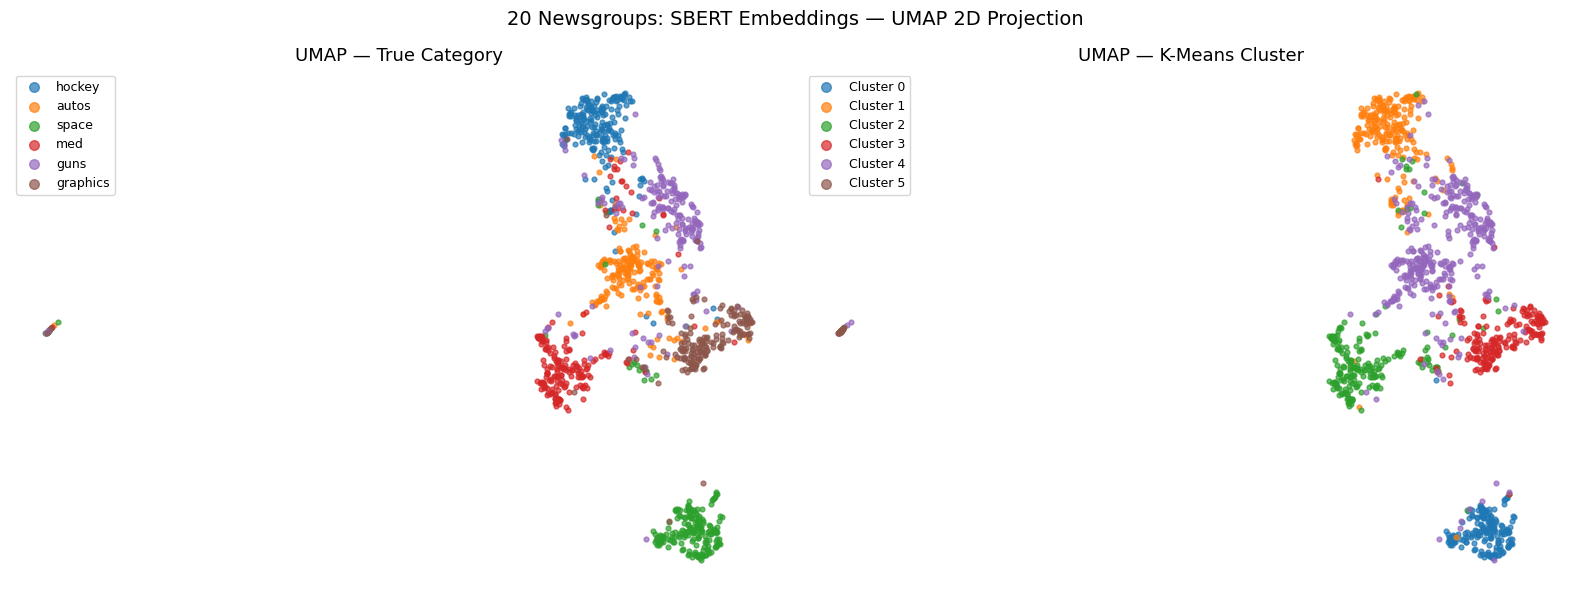

In [ ]:
# ── 2D via UMAP (best for dense embeddings) ──────────────────────────
try:
    import umap
    reducer_sbert = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    X_sbert_2d = reducer_sbert.fit_transform(X_sbert)
    proj_name = 'UMAP'
except ImportError:
    tsne_s = TSNE(n_components=2, perplexity=40, random_state=42)
    X_sbert_2d = tsne_s.fit_transform(X_sbert)
    proj_name = 't-SNE'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, lbs, title, use_cats in [
    (axes[0], y_sub,        f'{proj_name} — True Category', True),
    (axes[1], labels_sbert, f'{proj_name} — K-Means Cluster', False),
]:
    for c in range(6):
        mask = lbs == c
        label = short_cats[c] if use_cats else f'Cluster {c}'
        ax.scatter(X_sbert_2d[mask, 0], X_sbert_2d[mask, 1],
                   color=plt.get_cmap('tab10')(c), s=12, alpha=0.7, label=label)
    ax.set_title(title, fontsize=13)
    ax.legend(markerscale=2, fontsize=9)
    ax.axis('off')

plt.suptitle(f'20 Newsgroups: SBERT Embeddings — {proj_name} 2D Projection',
             fontsize=14)
plt.tight_layout()
plt.show()

## Hierarchical Clustering + Dendrogram

Посмотрим, как работает иерархическая агломеративная кластеризация.

Напомним, что **агломеративная кластеризация**:

«начинаем с отдельных точек → постепенно склеиваем самые похожие → получаем дерево слияний (дендрограмму) → можем разрезать на любом уровне и получить кластеры».

Метод Ward — один из самых популярных: на каждом шаге объединяет те два кластера, слияние которых минимизирует прирост внутрикластерной дисперсии.

В результате мы получаем матрицу связности (linkage matrix), в которой закодировано, какие точки/кластеры когда объединялись и на каком расстоянии.

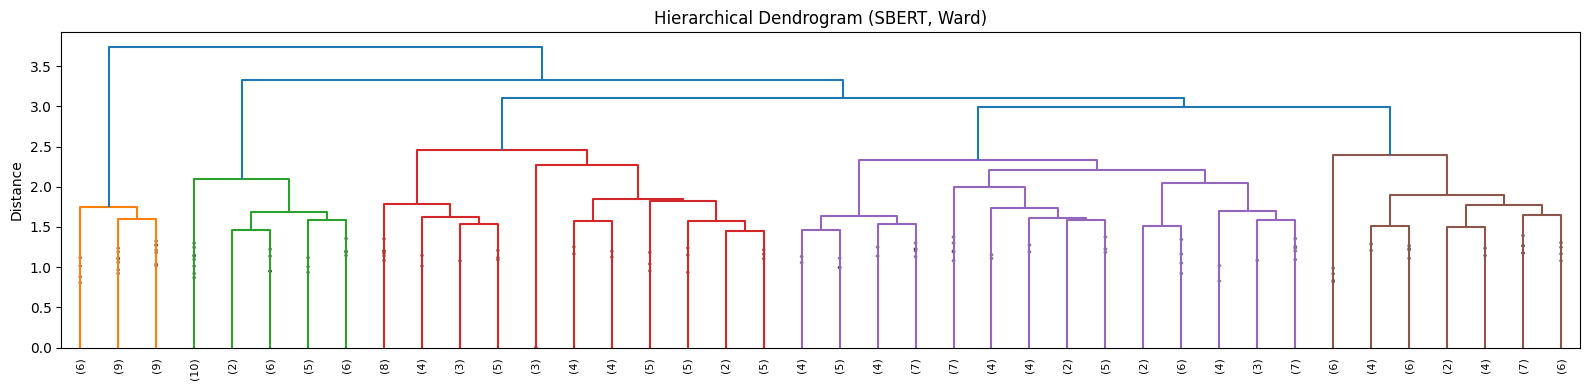

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

idx_d2 = np.random.default_rng(0).choice(len(X_sbert), 200, replace=False)
Z = linkage(X_sbert[idx_d2], method='ward')

fig, ax = plt.subplots(figsize=(16, 4))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=40,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True)
ax.set_title('Hierarchical Dendrogram (SBERT, Ward)', fontsize=12)
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
# ── Agglomerative Clustering ──────────────────────────────────────────
agglo = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_agglo = agglo.fit_predict(X_sbert)

ari_agglo = adjusted_rand_score(y_sub, labels_agglo)
sil_agglo = silhouette_score(X_sbert, labels_agglo, sample_size=500)
print(f'Agglomerative  →  ARI: {ari_agglo:.3f}  Silhouette: {sil_agglo:.3f}')

Agglomerative  →  ARI: 0.439  Silhouette: 0.056


## Задачи

1. Сравните различные подходы кластеризации текста. Какие из них работают быстрее, какие лучше? Постройте зависимость скорость vs качество.

2. Попробуйте понизить размерность, поможет ли это для улучшения качества кластеризации?